# A Neural Network for Iris flowers dataset

Download the iris dataset and then build a Neural Network model like the one in the figure. Show the classification accuracy achieved and try to tune the parameters (layers and properties) to measure the improvement.
<img src="images/nn_iris_dataset.png" width="70%"/>

In [30]:
from sklearn import datasets

iris_dataset = datasets.load_iris();

print("10 first samples of the dataset:", iris_dataset.data[1:10, :])
print("10 first labels of the dataset:", iris_dataset.target[1:10])


10 first samples of the dataset: [[4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]
10 first labels of the dataset: [0 0 0 0 0 0 0 0 0]


In [31]:
from sklearn.model_selection import train_test_split
from keras.utils.np_utils import to_categorical
from keras.utils import np_utils

X_train, X_test, y_train, y_test = train_test_split(
    iris_dataset.data, iris_dataset.target, test_size = 0.2, random_state = 0)

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

print(X_train.shape)
print(X_train[1:10,:])
print(X_train_sc[1:10,:])

#from sklearn.preprocessing import normalize #machine learning algorithm library
#from keras.utils import np_utils

#X_train_norm = normalize(X_train)
#X_test_norm = normalize(X_test)

y_train_onehot=np_utils.to_categorical(y_train,num_classes=3)
y_test_onehot=np_utils.to_categorical(y_test,num_classes=3)
print(y_train_onehot[1:10,:])

(120, 4)
[[5.4 3.  4.5 1.5]
 [5.2 3.5 1.5 0.2]
 [6.1 3.  4.9 1.8]
 [6.4 2.8 5.6 2.2]
 [5.2 2.7 3.9 1.4]
 [5.7 3.8 1.7 0.3]
 [6.  2.7 5.1 1.6]
 [5.9 3.  4.2 1.5]
 [5.8 2.6 4.  1.2]]
[[-0.56776627 -0.12400121  0.38491447  0.34752959]
 [-0.80392556  1.03851009 -1.30289562 -1.33615415]
 [ 0.25879121 -0.12400121  0.60995581  0.736072  ]
 [ 0.61303014 -0.58900572  1.00377816  1.25412853]
 [-0.80392556 -0.82150798  0.04735245  0.21801546]
 [-0.21352735  1.73601687 -1.19037495 -1.20664002]
 [ 0.14071157 -0.82150798  0.72247648  0.47704373]
 [ 0.02263193 -0.12400121  0.21613346  0.34752959]
 [-0.09544771 -1.05401024  0.10361279 -0.04101281]]
[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]]


In [22]:
from keras.models import Sequential
from keras.layers import Dense

neuralnet = Sequential()

# adding the first hidden layer 
neuralnet.add(Dense(units = 10, activation = 'relu', input_dim = 4 ))

# adding the second hidden layer 
neuralnet.add(Dense(units = 7, activation = 'relu'))



### SOFTMAX

<center><img src="images/softmax-function.jpg" width="30%"/>
<img src="images/iris_softmax.webp" width="70%"/></center>


In [23]:
# adding the output layer 
neuralnet.add(Dense(units = 3, activation = 'softmax')) 

neuralnet.compile(optimizer = 'adam', loss = 'binary_crossentropy' , metrics = ['accuracy'] )  

neuralnet.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_10 (Dense)             (None, 10)                50        
_________________________________________________________________
dense_11 (Dense)             (None, 7)                 77        
_________________________________________________________________
dense_12 (Dense)             (None, 3)                 24        
Total params: 151
Trainable params: 151
Non-trainable params: 0
_________________________________________________________________


In [24]:
# Fitting the ANN with the training set 
h = neuralnet.fit(X_train_sc, y_train_onehot, validation_split=0.33, batch_size=10, epochs = 150) 

Epoch 1/150
8/8 [==============================] - 0s 13ms/step - loss: 0.4802 - accuracy: 0.3125 - val_loss: 0.4653 - val_accuracy: 0.3750
Epoch 2/150
8/8 [==============================] - 0s 2ms/step - loss: 0.4700 - accuracy: 0.3625 - val_loss: 0.4554 - val_accuracy: 0.4000
Epoch 3/150
8/8 [==============================] - 0s 3ms/step - loss: 0.4617 - accuracy: 0.4125 - val_loss: 0.4471 - val_accuracy: 0.4250
Epoch 4/150
8/8 [==============================] - 0s 2ms/step - loss: 0.4550 - accuracy: 0.4500 - val_loss: 0.4400 - val_accuracy: 0.4750
Epoch 5/150
8/8 [==============================] - 0s 2ms/step - loss: 0.4484 - accuracy: 0.4750 - val_loss: 0.4340 - val_accuracy: 0.4750
Epoch 6/150
8/8 [==============================] - 0s 2ms/step - loss: 0.4429 - accuracy: 0.5375 - val_loss: 0.4284 - val_accuracy: 0.5250
Epoch 7/150
8/8 [==============================] - 0s 2ms/step - loss: 0.4372 - accuracy: 0.5250 - val_loss: 0.4235 - val_accuracy: 0.5250
Epoch 8/150
8/8 [=========

In [25]:
import matplotlib.pyplot as plt

# list all data in history
print(h.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


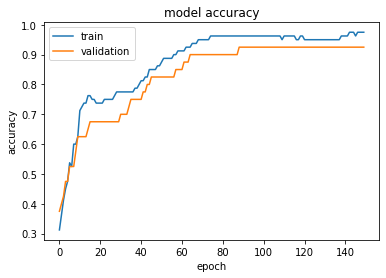

In [26]:
# summarize history for accuracy
plt.plot(h.history['accuracy'])
plt.plot(h.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

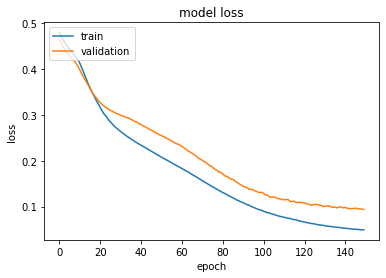

In [27]:
# summarize history for loss
plt.plot(h.history['loss'])
plt.plot(h.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

## Let's try with a wider NN model

In [28]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.layers.normalization import BatchNormalization 


model=Sequential()
model.add(Dense(1000,input_dim=4,activation='relu'))
model.add(Dense(700,activation='relu'))
model.add(Dense(200,activation='relu'))
#model.add(Dropout(0.2))
model.add(Dense(3,activation='softmax'))
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
h2=model.fit(X_train_sc, y_train_onehot, validation_split=0.33, batch_size=2, epochs=100, verbose=1)

Epoch 1/100
40/40 [==============================] - 0s 6ms/step - loss: 0.2923 - accuracy: 0.8250 - val_loss: 0.1540 - val_accuracy: 0.8500
Epoch 2/100
40/40 [==============================] - 0s 4ms/step - loss: 0.1857 - accuracy: 0.8625 - val_loss: 0.3756 - val_accuracy: 0.7500
Epoch 3/100
40/40 [==============================] - 0s 4ms/step - loss: 0.1497 - accuracy: 0.9250 - val_loss: 0.0805 - val_accuracy: 0.9250
Epoch 4/100
40/40 [==============================] - 0s 4ms/step - loss: 0.2397 - accuracy: 0.8875 - val_loss: 0.3083 - val_accuracy: 0.9000
Epoch 5/100
40/40 [==============================] - 0s 4ms/step - loss: 0.1367 - accuracy: 0.9250 - val_loss: 0.1540 - val_accuracy: 0.9250
Epoch 6/100
40/40 [==============================] - 0s 4ms/step - loss: 0.0782 - accuracy: 0.9625 - val_loss: 0.0660 - val_accuracy: 0.9500
Epoch 7/100
40/40 [==============================] - 0s 4ms/step - loss: 0.0935 - accuracy: 0.9750 - val_loss: 0.0659 - val_accuracy: 0.9500
Epoch 8/100
4

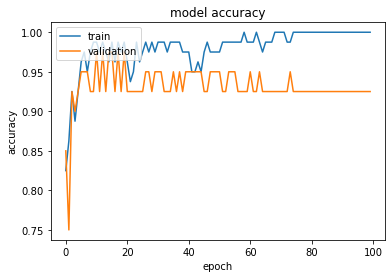

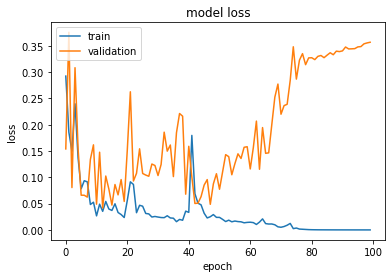

In [29]:
import matplotlib.pyplot as plt

# summarize history for accuracy
plt.plot(h2.history['accuracy'])
plt.plot(h2.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# summarize history for loss
plt.plot(h2.history['loss'])
plt.plot(h2.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()